# AgriVision AI
Plant Disease Classification using Vision Transformers (ViT)

Dataset:
PlantVillage

Classes:
- Potato Early Blight
- Potato Late Blight
- Potato Healthy
- Tomato Early Blight
- Tomato Late Blight
- Tomato Healthy

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# PyTorch
import torch
from torch.utils.data import random_split, DataLoader, Subset

# TorchVision
from torchvision import datasets, transforms

!pip install -q transformers

In [3]:
dataset_path = "/content/drive/MyDrive/AgriVision-AI/Project_Dataset"

In [4]:
# Basic preprocessing used for dataset exploration and visualization
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)
print(dataset.classes)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']


In [5]:
print("Total Images:", len(dataset))

Total Images: 6652


## Class Distribution Analysis

Before training, the class distribution is analyzed to identify possible imbalance among disease categories. Understanding class frequencies helps determine whether techniques such as class weighting are required during training.


In [6]:
# Read labels directly from ImageFolder metadata without loading images
targets = dataset.targets
class_counts = Counter(targets)

for idx, count in class_counts.items():
    print(dataset.classes[idx], ":", count)

Potato___Early_blight : 1000
Potato___Late_blight : 1000
Potato___healthy : 152
Tomato_Early_blight : 1000
Tomato_Late_blight : 1909
Tomato_healthy : 1591


## Dataset Visualization

Random samples are displayed to verify image quality, class labels, and dataset integrity before model training.


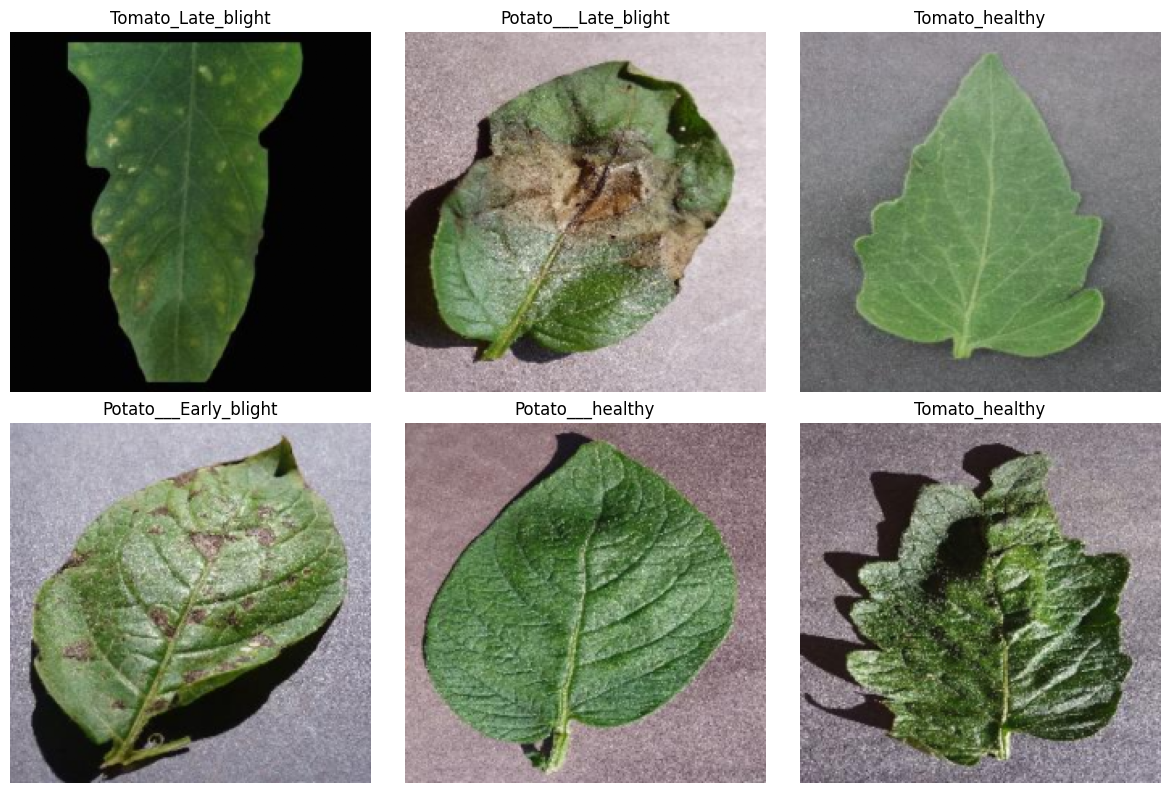

In [7]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax in axes.flatten():

    idx = np.random.randint(len(dataset))

    image, label = dataset[idx]

    image = image.permute(1,2,0)

    ax.imshow(image)

    ax.set_title(dataset.classes[label])

    ax.axis("off")

plt.tight_layout()
plt.show()

## Environment Verification

In [8]:
print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
Tesla T4


## Data Augmentation

Training images are augmented using flipping, rotation, and color transformations to improve generalization and reduce overfitting. Validation and test images use only resizing and tensor conversion.

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(), # Farmers won't always take perfectly aligned photos.
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ), # Different sunlight, camera quality, shadows
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [10]:
# Create dataset without transforms
base_dataset = datasets.ImageFolder(
    root=dataset_path
)

train_size = int(0.7 * len(base_dataset))
val_size = int(0.15 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

In [11]:
# Create Datasets with Different Transforms
train_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform
)

## Dataset Splitting

The dataset is divided into training, validation, and test sets using a 70:15:15 ratio. A fixed random seed ensures reproducibility across experiments.


In [12]:
train_dataset = Subset(
    train_dataset,
    train_subset.indices
)

val_dataset = Subset(
    val_dataset,
    val_subset.indices
)

test_dataset = Subset(
    test_dataset,
    test_subset.indices
)

## Data Loaders

PyTorch DataLoaders are used to efficiently batch and shuffle images during training and evaluation.


In [13]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

## Vision Transformer Initialization

A pre-trained Vision Transformer (ViT-Base Patch16-224) is used as the backbone model. Transfer learning enables the model to leverage features learned from large-scale image datasets while adapting to plant disease classification.


In [14]:
from transformers import ViTForImageClassification
import torch.nn as nn

# Load Pretrained ViT
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

## Replacing the Classifier for Our Dataset

In [15]:
model.classifier = nn.Linear(model.config.hidden_size,6)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
print(device)

cuda


##Handling Class Imbalance Properly
| Class              | Images |
| ------------------ | -----: |
| Potato Healthy     |    152 |
| Tomato Late Blight |   1909 |

This imbalance is significant.
To prevent the model from favoring majority classes, balanced class weights are computed and incorporated into the loss function.

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

targets = base_dataset.targets

class_weights = compute_class_weight(class_weight="balanced",
    classes=np.unique(targets),y=targets)

print(class_weights)

[1.10866667 1.10866667 7.29385965 1.10866667 0.58075781 0.69683637]


## Loss Function and Optimizer

Weighted Cross Entropy Loss is used to address class imbalance, while AdamW is selected as the optimizer due to its strong performance with transformer-based architectures.

In [18]:
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [19]:
# Create Optimizer
from torch.optim import AdamW

optimizer = AdamW(model.parameters(),lr=2e-5)

In [20]:
# Compute classification accuracy on a given dataset.
def evaluate(model, dataloader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.logits,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

## Model Training

The Vision Transformer is trained for 5 epochs using transfer learning. Validation accuracy is monitored after each epoch, and the best-performing model checkpoint is saved automatically.

In [21]:
NUM_EPOCHS = 5
BEST_VAL_ACC = 0

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs.logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    val_acc = evaluate(model, val_loader, device)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {avg_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%")

    if val_acc > BEST_VAL_ACC:

        BEST_VAL_ACC = val_acc

        torch.save(model.state_dict(), "best_vit_agrivision.pth")

        print("Best model saved!")

Epoch [1/5] Loss: 0.2912 Val Acc: 98.80%
Best model saved!
Epoch [2/5] Loss: 0.0288 Val Acc: 99.60%
Best model saved!
Epoch [3/5] Loss: 0.0098 Val Acc: 99.80%
Best model saved!
Epoch [4/5] Loss: 0.0122 Val Acc: 99.50%
Epoch [5/5] Loss: 0.0205 Val Acc: 98.90%


In [22]:
print("Best Validation Accuracy:", BEST_VAL_ACC)

Best Validation Accuracy: 99.79939819458374


## Final Model Evaluation

The best checkpoint is evaluated on the held-out test set to estimate real-world performance.

In [23]:
test_accuracy = evaluate(model, test_loader, device)

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.40%


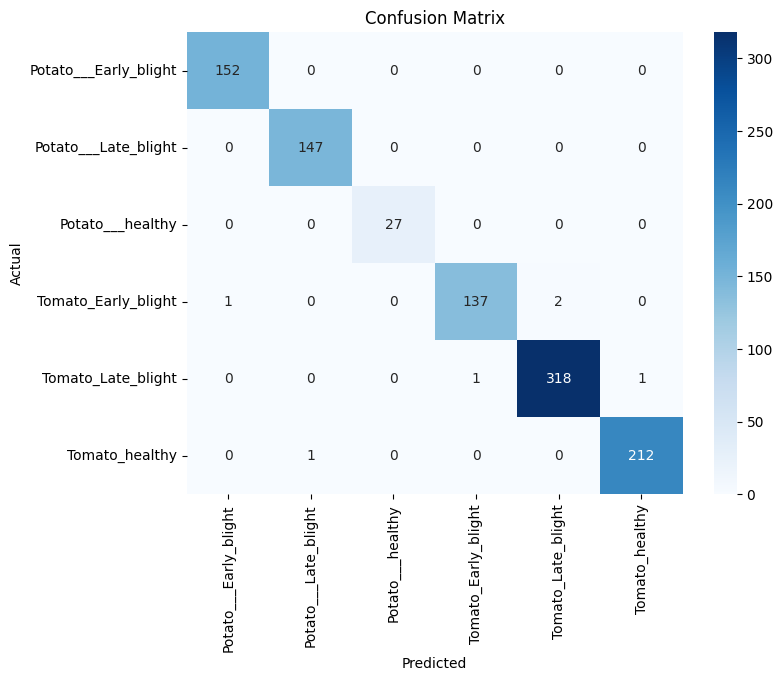

In [24]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
# Generate Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

                       precision    recall  f1-score   support

Potato___Early_blight       0.99      1.00      1.00       152
 Potato___Late_blight       0.99      1.00      1.00       147
     Potato___healthy       1.00      1.00      1.00        27
  Tomato_Early_blight       0.99      0.98      0.99       140
   Tomato_Late_blight       0.99      0.99      0.99       320
       Tomato_healthy       1.00      1.00      1.00       213

             accuracy                           0.99       999
            macro avg       0.99      0.99      0.99       999
         weighted avg       0.99      0.99      0.99       999



## Model Serialization

In [26]:
# Saving Everything
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": base_dataset.classes
    }, "agrivision_vit_model.pth")

print("Model saved successfully")

Model saved successfully


## Inference Pipeline

A reusable prediction function is created to perform disease classification on unseen plant leaf images. The function returns both the predicted class and model confidence score.

In [27]:
from PIL import Image
import torch

class_names = base_dataset.classes

# Predicting plant disease from a single image.
def predict_image(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    image = test_transform(image)

    image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():

        outputs = model(image)

        probabilities = torch.softmax(outputs.logits, dim=1)

        confidence, prediction = torch.max(probabilities, dim=1)

    predicted_class = class_names[prediction.item()]

    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score

## Real-World Image Testing

To evaluate practical usability, the trained model was tested on external plant leaf images collected from internet sources rather than the PlantVillage dataset.

These images introduce real-world challenges including:

* Variable lighting conditions
* Complex backgrounds
* Different camera devices
* Varying zoom levels
* Leaf orientation changes

This evaluation helps assess the model's ability to generalize beyond the controlled dataset environment.


In [33]:
test_images = ["/content/real_test image1 Potato Early Blight.png",
    "/content/real_test image2 Potato Late Blight.png",
    "/content/real_test image3 Tomato Early Blight.png",
    "/content/real_test image4 Tomato healthy.png"]

for image_path in test_images:

    prediction, confidence = predict_image(image_path)

    print("=" * 60)
    print("Image:", image_path.split("/")[-1])
    print("Prediction:", prediction)
    print(f"Confidence: {confidence:.2f}%")

Image: real_test image1 Potato Early Blight.png
Prediction: Potato___Early_blight
Confidence: 94.02%
Image: real_test image2 Potato Late Blight.png
Prediction: Potato___Late_blight
Confidence: 80.51%
Image: real_test image3 Tomato Early Blight.png
Prediction: Potato___Early_blight
Confidence: 89.79%
Image: real_test image4 Tomato healthy.png
Prediction: Tomato_Late_blight
Confidence: 49.95%


### Observations

The model achieved strong performance on PlantVillage test data but showed reduced confidence and occasional misclassification on real-world images.

This highlights the domain shift problem commonly encountered in computer vision systems when moving from controlled datasets to field conditions.

Future improvements include collecting field images, stronger augmentation strategies, and fine-tuning on more diverse agricultural datasets.
